# PubLayNet Benchmark: Native PyMuPDF Layout

This notebook measures PyMuPDF Layout directly on native, selectable-text PDFs.
It intentionally does **not** use OCR. That keeps the experiment simple and avoids mixing OCR errors with layout-analysis errors.

The local project contains 10 native pages matched to the existing PubLayNet sample images and annotations. This is a verified 10-page subset, not the full PubLayNet corpus.

Workflow:

1. Load the existing PubLayNet ground-truth boxes.
2. Open each native PDF page.
3. Ask PyMuPDF Layout for its classified boxes.
4. Map PyMuPDF labels to PubLayNet labels.
5. Match boxes using class-specific IoU.
6. Save metrics and predictions.

In [56]:
from collections import Counter
import json
from pathlib import Path
from time import perf_counter

import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import pandas as pd
from PIL import Image
import pymupdf
import pymupdf4llm  # Activates the PyMuPDF Layout model.

print("Python:", __import__("sys").version.split()[0])
print("PyMuPDF:", pymupdf.__version__)
print("PyMuPDF4LLM:", pymupdf4llm.version)

Python: 3.13.5
PyMuPDF: 1.28.2
PyMuPDF4LLM: 1.28.2


In [65]:
ROOT = Path("..").resolve()
NATIVE_PAGE_DIR = ROOT / "data" / "publaynet_native" / "pages"
GROUND_TRUTH_PATH = ROOT / "outputs" / "publaynet" / "publaynet_predictions.json"
OUTPUT_DIR = ROOT / "outputs" / "publaynet" / "native_only"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
IOU_THRESHOLD = 0.50

PUBLAYNET_TO_CLASS = {
    1: "text",
    2: "title",
    3: "list",
    4: "table",
    5: "figure",
}
CLASSES = ["text", "title", "list", "table", "figure"]

PYMUPDF_TO_PUBLAYNET = {
    "text": "text",
    "caption": "text",
    "footnote": "text",
    "page-header": "text",
    "page-footer": "text",
    "title": "title",
    "section-header": "title",
    "list-item": "list",
    "table": "table",
    "picture": "figure",
}

print("Native pages:", NATIVE_PAGE_DIR)
print("Ground truth:", GROUND_TRUTH_PATH)

Native pages: C:\Users\oscar\Documents\CMU\Mini 5\Capstone\pymupdf4llm-benchmark\data\publaynet_native\pages
Ground truth: C:\Users\oscar\Documents\CMU\Mini 5\Capstone\pymupdf4llm-benchmark\outputs\publaynet\publaynet_predictions.json


In [58]:
saved_records = json.loads(GROUND_TRUTH_PATH.read_text(encoding="utf-8"))
ground_truth_by_id = {
    record["sample_id"]: record["ground_truth"]
    for record in saved_records
}

pdf_paths = sorted(NATIVE_PAGE_DIR.glob("publaynet_*.pdf"))
if not pdf_paths:
    raise RuntimeError(f"No native PDFs found in {NATIVE_PAGE_DIR}")

missing_annotations = [
    path.stem.replace("publaynet_", "")
    for path in pdf_paths
    if path.stem.replace("publaynet_", "") not in ground_truth_by_id
]
if missing_annotations:
    raise RuntimeError(f"Missing ground truth for: {missing_annotations}")

print(f"Found {len(pdf_paths)} native pages with matching annotations.")

Found 10 native pages with matching annotations.


In [59]:
def intersection_over_union(box_a, box_b):
    ax0, ay0, ax1, ay1 = box_a
    bx0, by0, bx1, by1 = box_b
    intersection = max(0.0, min(ax1, bx1) - max(ax0, bx0)) * max(
        0.0, min(ay1, by1) - max(ay0, by0)
    )
    area_a = max(0.0, ax1 - ax0) * max(0.0, ay1 - ay0)
    area_b = max(0.0, bx1 - bx0) * max(0.0, by1 - by0)
    union = area_a + area_b - intersection
    return intersection / union if union else 0.0


def match_one_class(ground_truth, predictions):
    candidates = [
        (intersection_over_union(gt, prediction), gt_index, prediction_index)
        for gt_index, gt in enumerate(ground_truth)
        for prediction_index, prediction in enumerate(predictions)
    ]
    candidates.sort(reverse=True)
    matched_gt = set()
    matched_predictions = set()
    matched_ious = []

    for iou, gt_index, prediction_index in candidates:
        if iou < IOU_THRESHOLD:
            break
        if gt_index in matched_gt or prediction_index in matched_predictions:
            continue
        matched_gt.add(gt_index)
        matched_predictions.add(prediction_index)
        matched_ious.append(iou)

    true_positive = len(matched_ious)
    return (
        true_positive,
        len(predictions) - true_positive,
        len(ground_truth) - true_positive,
        matched_ious,
    )

In [60]:
records = []

for pdf_path in pdf_paths:
    sample_id = pdf_path.stem.replace("publaynet_", "")
    start = perf_counter()

    with pymupdf.open(pdf_path) as document:
        if len(document) != 1:
            raise RuntimeError(f"Expected one page: {pdf_path}")
        page = document[0]
        page.get_layout(return_raw=True)
        raw_boxes = page.layout_information or []
        if not raw_boxes:
            raise RuntimeError(f"No layout boxes returned: {pdf_path}")

        predictions = []
        for raw_box in raw_boxes:
            raw_class = raw_box["class_name"]
            mapped_class = PYMUPDF_TO_PUBLAYNET.get(raw_class)
            if mapped_class is None:
                continue
            predictions.append({
                "class": mapped_class,
                "raw_class": raw_class,
                "bbox": [float(value) for value in raw_box["group_bbox"]],
            })

        if not predictions:
            raise RuntimeError(f"No mapped predictions returned: {pdf_path}")

        records.append({
            "sample_id": sample_id,
            "ground_truth": ground_truth_by_id[sample_id],
            "predictions": predictions,
            "raw_boxes": len(raw_boxes),
            "raw_classes": dict(Counter(box["class_name"] for box in raw_boxes)),
            "page_size": [float(page.rect.width), float(page.rect.height)],
            "text_characters": len(page.get_text()),
            "runtime_seconds": perf_counter() - start,
        })

first_page = records[0]
print("First page:", first_page["sample_id"])
print("Extracted text characters:", first_page["text_characters"])
print("Raw layout classes:", first_page["raw_classes"])
print("Raw layout boxes:", first_page["raw_boxes"])
print("Mapped prediction boxes:", len(first_page["predictions"]))
print("Page dimensions:", first_page["page_size"])
print("Runtime seconds:", round(first_page["runtime_seconds"], 3))
print("Completed pages:", len(records))

First page: 409598
Extracted text characters: 2066
Raw layout classes: {'page-header': 2, 'caption': 1, 'table': 1, 'text': 5, 'page-footer': 1}
Raw layout boxes: 10
Mapped prediction boxes: 10
Page dimensions: [612.0, 792.0]
Runtime seconds: 0.754
Completed pages: 10


In [61]:
totals = {
    class_name: {"tp": 0, "fp": 0, "fn": 0, "ious": []}
    for class_name in CLASSES
}
per_page_rows = []

for record in records:
    page_counts = {"tp": 0, "fp": 0, "fn": 0}
    for class_name in CLASSES:
        ground_truth = [
            box["bbox"]
            for box in record["ground_truth"]
            if box["class"] == class_name
        ]
        predictions = [
            box["bbox"]
            for box in record["predictions"]
            if box["class"] == class_name
        ]
        tp, fp, fn, ious = match_one_class(ground_truth, predictions)
        totals[class_name]["tp"] += tp
        totals[class_name]["fp"] += fp
        totals[class_name]["fn"] += fn
        totals[class_name]["ious"].extend(ious)
        page_counts["tp"] += tp
        page_counts["fp"] += fp
        page_counts["fn"] += fn

    per_page_rows.append({
        "sample_id": record["sample_id"],
        "ground_truth_boxes": len(record["ground_truth"]),
        "predicted_boxes": len(record["predictions"]),
        **page_counts,
        "runtime_seconds": record["runtime_seconds"],
    })

metric_rows = []
for class_name in CLASSES:
    values = totals[class_name]
    tp, fp, fn = values["tp"], values["fp"], values["fn"]
    precision = tp / (tp + fp) if tp + fp else 0.0
    recall = tp / (tp + fn) if tp + fn else 0.0
    f1 = 2 * precision * recall / (precision + recall) if precision + recall else 0.0
    mean_iou = sum(values["ious"]) / len(values["ious"]) if values["ious"] else 0.0
    metric_rows.append({
        "class": class_name,
        "tp": tp,
        "fp": fp,
        "fn": fn,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "mean_matched_iou": mean_iou,
    })

metrics_df = pd.DataFrame(metric_rows)
per_page_df = pd.DataFrame(per_page_rows)
summary = {
    "pathway": "native selectable-text PDF -> PyMuPDF Layout; no OCR",
    "pages": len(records),
    "iou_threshold": IOU_THRESHOLD,
    "macro_precision": float(metrics_df["precision"].mean()),
    "macro_recall": float(metrics_df["recall"].mean()),
    "macro_f1": float(metrics_df["f1"].mean()),
    "mean_runtime_seconds": float(per_page_df["runtime_seconds"].mean()),
    "note": "Matched native-page subset currently available locally; not the full PubLayNet corpus.",
}

metrics_df

,class,tp,fp,fn,precision,recall,f1,mean_matched_iou
0,text,107,33,3,0.764286,0.972727,0.856000,0.944257
1,title,18,1,0,0.947368,1.000000,0.972973,0.767458
2,list,1,23,4,0.041667,0.200000,0.068966,0.541033
3,table,7,0,0,1.000000,1.000000,1.000000,0.914648
4,figure,0,0,0,0.000000,0.000000,0.000000,0.000000


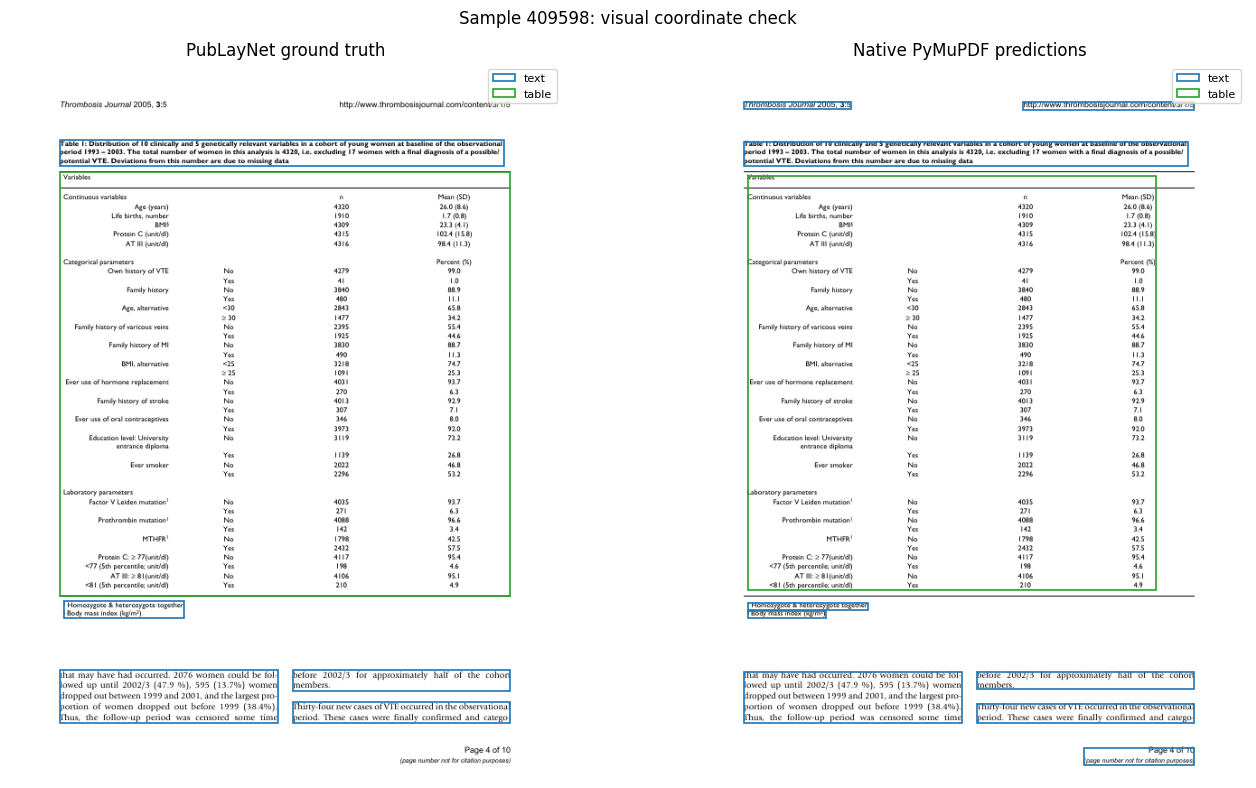

In [62]:
CLASS_COLORS = {
    "text": "tab:blue",
    "title": "tab:orange",
    "list": "tab:purple",
    "table": "tab:green",
    "figure": "tab:red",
}


def draw_boxes(axis, image, boxes, title):
    axis.imshow(image)
    axis.set_title(title)
    axis.axis("off")
    used_labels = set()
    for box in boxes:
        class_name = box["class"]
        x0, y0, x1, y1 = box["bbox"]
        label = class_name if class_name not in used_labels else None
        used_labels.add(class_name)
        axis.add_patch(Rectangle(
            (x0, y0), x1 - x0, y1 - y0,
            fill=False, linewidth=1.2,
            edgecolor=CLASS_COLORS[class_name], label=label,
        ))
    if used_labels:
        axis.legend(loc="upper right", fontsize=8)


record = records[0]
image_path = ROOT / "data" / "publaynet_sample" / f"publaynet_{record['sample_id']}.png"
image = Image.open(image_path).convert("RGB")
figure, axes = plt.subplots(1, 2, figsize=(14, 8))
draw_boxes(axes[0], image, record["ground_truth"], "PubLayNet ground truth")
draw_boxes(axes[1], image, record["predictions"], "Native PyMuPDF predictions")
figure.suptitle(f"Sample {record['sample_id']}: visual coordinate check")
figure.tight_layout()
figure.savefig(OUTPUT_DIR / f"native_overlay_{record['sample_id']}.png", dpi=120)
plt.show()
plt.close(figure)

In [63]:
metrics_df.to_csv(OUTPUT_DIR / "native_class_metrics.csv", index=False)
per_page_df.to_csv(OUTPUT_DIR / "native_per_page_metrics.csv", index=False)
(OUTPUT_DIR / "native_predictions.json").write_text(
    json.dumps(records, indent=2), encoding="utf-8"
)
(OUTPUT_DIR / "native_summary.json").write_text(
    json.dumps(summary, indent=2), encoding="utf-8"
)

print(json.dumps(summary, indent=2))
print("Saved results to:", OUTPUT_DIR)

{
  "pathway": "native selectable-text PDF -> PyMuPDF Layout; no OCR",
  "pages": 10,
  "iou_threshold": 0.5,
  "macro_precision": 0.5506641604010024,
  "macro_recall": 0.6345454545454545,
  "macro_f1": 0.5795876980428705,
  "mean_runtime_seconds": 0.6935240900013013,
  "note": "Matched native-page subset currently available locally; not the full PubLayNet corpus."
}
Saved results to: C:\Users\oscar\Documents\CMU\Mini 5\Capstone\pymupdf4llm-benchmark\outputs\publaynet\native_only
